<h1> RELEVANCE GATE PROJECT</h1>

<h2>importing inportant liberies</h2>

In [ ]:
# used for data manipulation
import numpy as np
import pandas as pd
# used for data visualization
import matplotlib.pyplot as plt
#used for train_test splitting
from sklearn.model_selection import train_test_split
#used for text vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
#machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
# Evaluation matrix
from sklearn.metrics import (
     accuracy_score,
     precision_score,
     recall_score,f1_score,
     classification_report,
     confusion_matrix,
     ConfusionMatrixDisplay
 )
#model persistence
import joblib
#utilities
import os
import re
# Display settings
pd.set_option("display.max_colwidth",200)
pd.set_option("display.max_columns",None)
print("All libraries are succesfully installed")
import streamlit as st #python framework for ml

All libraries are succesfully installed


<h2>Reading, inspecting, cleaning and validating the dataset</h2>

In [ ]:
df = pd.read_csv("relevance_gate_dataset.csv")
df.head()

,question,label,category
0,What are the system requirements for FIFA 26?,irrelevant,video_games
1,What textbook is required for Physics II?,relevant,course
2,What is the weather like in Seoul in April?,irrelevant,travel
3,How long is the final exam for General Chemistry?,relevant,exam
4,Is Introduction to Biology a mandatory course for my major?,relevant,course


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape: (2000, 3)

Columns:
['question', 'label', 'category']

First 5 rows:


,question,label,category
0,What are the system requirements for FIFA 26?,irrelevant,video_games
1,What textbook is required for Physics II?,relevant,course
2,What is the weather like in Seoul in April?,irrelevant,travel
3,How long is the final exam for General Chemistry?,relevant,exam
4,Is Introduction to Biology a mandatory course for my major?,relevant,course



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   question  2000 non-null   str  
 1   label     2000 non-null   str  
 2   category  2000 non-null   str  
dtypes: str(3)
memory usage: 171.9 KB

Missing values:
question    0
label       0
category    0
dtype: int64

Duplicate rows:
0


In [ ]:
#checking for repeated questions
question_counts = df["question"].value_counts()
duplicates = question_counts[question_counts > 1]
print("Questions appearing more than once:", len(duplicates))


Questions appearing more than once: 0


In [ ]:
print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nLabel percentages:")
print(df["label"].value_counts(normalize=True) * 100)

# 3. Category distribution
print("\nCategory distribution:")
print(df["category"].value_counts())



Label distribution:
label
irrelevant    1000
relevant      1000
Name: count, dtype: int64

Label percentages:
label
irrelevant    50.0
relevant      50.0
Name: proportion, dtype: float64

Category distribution:
category
course                334
exam                  270
entertainment         209
assignment            162
music                 135
travel                134
video_games            97
creative_writing       96
admissions             82
cooking                76
faculty                54
cars                   34
weather                28
sports                 27
general_trivia         26
finance                21
shopping               20
technology             20
health_fitness         12
policy                 11
home_improvement       10
fashion                10
smalltalk              10
animals                10
gardening              10
math_content            9
biology_content         8
library_research        8
relationships           8
psychology_content      7

In [ ]:
display(
    (pd.crosstab(
        df["category"],
        df["label"],
        normalize="index"
    ) * 100).round(2)
)

label,irrelevant,relevant
category,,
admissions,0.0,100.0
animals,100.0,0.0
assignment,0.0,100.0
biology_content,0.0,100.0
cars,100.0,0.0
chemistry_content,0.0,100.0
cooking,100.0,0.0
course,0.0,100.0
creative_writing,100.0,0.0


In [ ]:
display(
    (pd.crosstab(
        df["category"],
        df["label"],
        normalize="index"
    ) * 100).round(2)
)

label,irrelevant,relevant
category,,
admissions,0.0,100.0
animals,100.0,0.0
assignment,0.0,100.0
biology_content,0.0,100.0
cars,100.0,0.0
chemistry_content,0.0,100.0
cooking,100.0,0.0
course,0.0,100.0
creative_writing,100.0,0.0


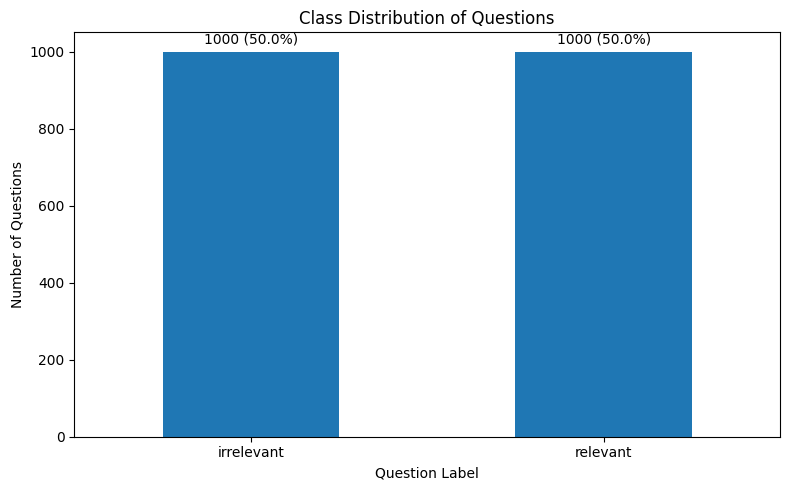

In [ ]:
label_counts = df["label"].value_counts()
plt.figure(figsize=(8, 5))

ax = label_counts.plot(kind="bar")

plt.title("Class Distribution of Questions")
plt.xlabel("Question Label")
plt.ylabel("Number of Questions")

plt.xticks(rotation=0)

total = len(df)

for i, value in enumerate(label_counts):
    percentage = (value / total) * 100
    
    ax.text(
        i,
        value + 20,
        f"{value} ({percentage:.1f}%)",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "visualizations/class_balance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print(os.getcwd())

c:\Users\user


In [ ]:
df["word_count"] = df["question"].str.split().str.len()
df["word_count"].describe()

count    2000.000000
mean        8.231000
std         2.089934
min         3.000000
25%         7.000000
50%         8.000000
75%        10.000000
max        14.000000
Name: word_count, dtype: float64

In [ ]:
df.head()

,question,label,category,word_count
0,What are the system requirements for FIFA 26?,irrelevant,video_games,8
1,What textbook is required for Physics II?,relevant,course,7
2,What is the weather like in Seoul in April?,irrelevant,travel,9
3,How long is the final exam for General Chemistry?,relevant,exam,9
4,Is Introduction to Biology a mandatory course for my major?,relevant,course,10


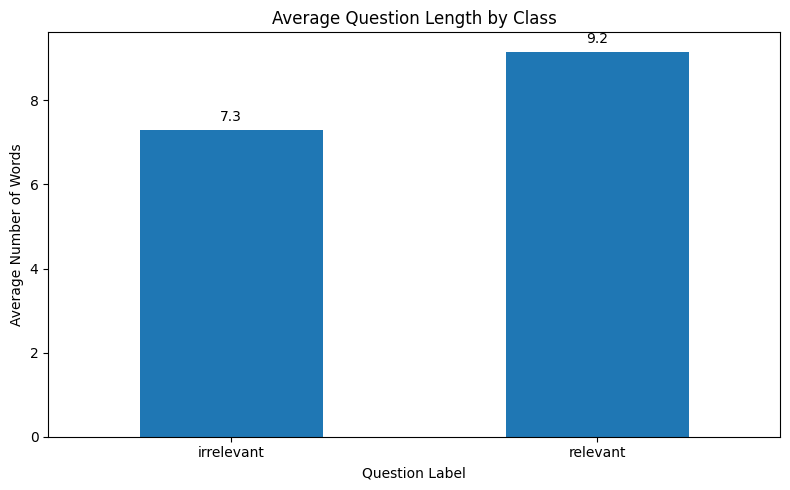

In [ ]:
plt.figure(figsize=(8, 5))

average_length = df.groupby("label")["word_count"].mean()

ax = average_length.plot(kind="bar")

plt.title("Average Question Length by Class")
plt.xlabel("Question Label")
plt.ylabel("Average Number of Words")

plt.xticks(rotation=0)

for i, value in enumerate(average_length):
    ax.text(
        i,
        value + 0.2,
        f"{value:.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

<h2>SLITTING DATA INTO TRAIN AND TEST</h2>

In [ ]:
X = df["question"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


In [ ]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1600
Testing samples: 400


In [ ]:
print("Training percentages:")
print(f"{y_train.value_counts(normalize=True) * 100}%")

print("\nTesting percentages:")
print(f"{y_test.value_counts(normalize=True) * 100}%")

Training percentages:
label
relevant      50.0
irrelevant    50.0
Name: proportion, dtype: float64%

Testing percentages:
label
irrelevant    50.0
relevant      50.0
Name: proportion, dtype: float64%


<h2> creating a vectorizer and using TfidfVectorizer</h2>

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

NameError: name 'tfidf' is not defined

In [ ]:
y_train_encoded = y_train.map({"relevant":1,"irrelevant":0})
y_test_encoded = y_test.map({"relevant":1,"irrelevant":0})
y_train_encoded.head()
y_test_encoded.head()


1514    0
52      0
150     1
970     0
1022    0
Name: label, dtype: int64

In [ ]:
print("Number of features:", len(tfidf.get_feature_names_out()))

Number of features: 1060


In [ ]:
print(tfidf.get_feature_names_out()[:60])

['101' '150' '2010' '2011' '2012' '2013' '2017' '2020' '2021' '2022'
 '2023' '2024' '2025' '2026' '2077' '26' '5x' 'about' 'absences'
 'abstract' 'academic' 'access' 'accessorize' 'account' 'accounting'
 'achu' 'acid' 'adele' 'adidas' 'administration' 'admission' 'admissions'
 'admitted' 'adults' 'adventure' 'advisor' 'africa' 'air' 'alade' 'album'
 'algebra' 'algorithms' 'all' 'allowed' 'altima' 'amazon' 'american'
 'amsterdam' 'an' 'anatomy' 'and' 'android' 'animal' 'anniversary'
 'another' 'antagonist' 'anthem' 'antivirus' 'any' 'apartments']


In [ ]:
print("Question:")
print(X_train.iloc[0])
print("\nTF-IDF vector:")
print(X_train_tfidf[0])

Question:
How much of my final grade is the Calculus II exam worth?

TF-IDF vector:
  (0, 438)	0.21097747817017254
  (0, 619)	0.3526630903958176
  (0, 659)	0.23957923252298968
  (0, 624)	0.29144099090129705
  (0, 340)	0.27611790739277775
  (0, 396)	0.37098978635412755
  (0, 471)	0.13311484385994835
  (0, 948)	0.129287388153622
  (0, 157)	0.37098978635412755
  (0, 445)	0.3643775063294402
  (0, 321)	0.22477662855672734
  (0, 1044)	0.34574984648850976


In [ ]:
# ============================================================
# LAYER 6 — TF-IDF VECTORIZATION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer


# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer()


# Fit ONLY on the training data
# and transform the training questions
X_train_tfidf = tfidf.fit_transform(X_train)


# Transform the test data using
# the vocabulary and IDF learned from training
X_test_tfidf = tfidf.transform(X_test)


# Display dimensions
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)


# Vocabulary information
print("\nNumber of TF-IDF features:",
      len(tfidf.get_feature_names_out()))


# Display first 50 vocabulary terms
print("\nFirst 50 vocabulary terms:")
print(tfidf.get_feature_names_out()[:50])


# Sparse matrix information
print("\nNumber of non-zero values:",
      X_train_tfidf.nnz)


print("\nMatrix type:")
print(type(X_train_tfidf))

Training TF-IDF shape: (1600, 1060)
Testing TF-IDF shape: (400, 1060)

Number of TF-IDF features: 1060

First 50 vocabulary terms:
['101' '150' '2010' '2011' '2012' '2013' '2017' '2020' '2021' '2022'
 '2023' '2024' '2025' '2026' '2077' '26' '5x' 'about' 'absences'
 'abstract' 'academic' 'access' 'accessorize' 'account' 'accounting'
 'achu' 'acid' 'adele' 'adidas' 'administration' 'admission' 'admissions'
 'admitted' 'adults' 'adventure' 'advisor' 'africa' 'air' 'alade' 'album'
 'algebra' 'algorithms' 'all' 'allowed' 'altima' 'amazon' 'american'
 'amsterdam' 'an' 'anatomy']

Number of non-zero values: 12216

Matrix type:
<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
Logistic_model = LogisticRegression(random_state = 42)

In [ ]:
Logistic_model

LogisticRegression(random_state=42)

In [ ]:
Logistic_model.fit(X_train_tfidf,y_train_encoded)
print(Logistic_model.classes_)

[0 1]


In [ ]:
y_predicted = Logistic_model.predict(X_test_tfidf)
y_predicted

array([0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,

In [ ]:
y_probabilities = Logistic_model.predict_proba(X_test_tfidf)
y_probabilities
relevant_probability = y_probabilities[:, 1]

In [ ]:
Results = pd.DataFrame({"QUESTION":X_test,"ACTUAL_LABEL":y_test_encoded,"PREDICTION":y_predicted,"RELEVANT_PROBABILITIES":relevant_probability})

In [ ]:
Results

,QUESTION,ACTUAL_LABEL,PREDICTION,RELEVANT_PROBABILITIES
1514,What is the best way to save money each month?,0,0,0.300679
52,What is the difference between 4G and 5G?,0,0,0.465247
150,What documents do I need for my application to Business Administration?,1,1,0.756800
970,Who sang Espresso?,0,0,0.143574
1022,What awards did Euphoria win?,0,0,0.100732
...,...,...,...,...
1249,What are Professor Ngwa's office hours?,1,1,0.785628
1640,What ingredients do I need for chocolate cake?,0,0,0.194872
214,What is the recipe for beef lasagna?,0,0,0.233424
1314,What genre is Taylor Swift known for?,0,0,0.160209


In [ ]:
Results.head(10)

,QUESTION,ACTUAL_LABEL,PREDICTION,RELEVANT_PROBABILITIES
1514,What is the best way to save money each month?,0,0,0.300679
52,What is the difference between 4G and 5G?,0,0,0.465247
150,What documents do I need for my application to Business Administration?,1,1,0.756800
970,Who sang Espresso?,0,0,0.143574
1022,What awards did Euphoria win?,0,0,0.100732
1006,How many credit hours is Cell Biology worth?,1,1,0.880218
61,What caused the Great Depression?,1,0,0.343619
655,Write a joke about a rainy day.,0,0,0.069698
1003,What is the weather like in Marrakesh in June?,0,0,0.081413
1663,Is the Financial Accounting exam open-book or closed-book?,1,1,0.917669


In [ ]:
accuracy = accuracy_score(
    y_test_encoded,
    y_predicted
)
print(f"ACCURACY: {accuracy*100}%")

ACCURACY: 94.0%


In [ ]:
accuracy = accuracy_score(y_test_encoded, y_predicted)

precision = precision_score(
    y_test_encoded,
    y_predicted,
    pos_label=1
)

recall = recall_score(
    y_test_encoded,
    y_predicted,
    pos_label=1
)

f1 = f1_score(
    y_test_encoded,
    y_predicted,
    pos_label=1
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.9400
Precision: 0.9835
Recall:    0.8950
F1-score:  0.9372


In [ ]:
print(
    classification_report(
        y_test_encoded,
        y_predicted,
        target_names=["irrelevant", "relevant"]
    )
)

              precision    recall  f1-score   support

  irrelevant       0.90      0.98      0.94       200
    relevant       0.98      0.90      0.94       200

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



In [ ]:
false_negatives = Results[
    (Results["ACTUAL_LABEL"] == 1) &
    (Results["PREDICTION"] == 0)
].copy()

print("False Negatives:", len(false_negatives))

display(false_negatives)

False Negatives: 21


,QUESTION,ACTUAL_LABEL,PREDICTION,RELEVANT_PROBABILITIES
61,What caused the Great Depression?,1,0,0.343619
1792,What is the law of supply and demand?,1,0,0.445369
584,What is the time complexity of binary search?,1,0,0.214201
781,What is the central theme of 'To Kill a Mockingbird'?,1,0,0.407979
1817,How does natural selection drive evolution?,1,0,0.316549
918,How do you calculate the standard deviation of a dataset?,1,0,0.283625
127,How do I cite a website using APA format?,1,0,0.387075
865,"How does Ohm's law relate voltage, current, and resistance?",1,0,0.428300
177,How do I prepare a study schedule for finals week?,1,0,0.477459
8,Explain Maslow's hierarchy of needs.,1,0,0.391594


In [ ]:
false_positives = Results[
    (Results["ACTUAL_LABEL"] == 0) &
    (Results["PREDICTION"] == 1)
].copy()

print("False Positives:", len(false_positives))

display(false_positives)

False Positives: 3


,QUESTION,ACTUAL_LABEL,PREDICTION,RELEVANT_PROBABILITIES
1550,How many bones are in the human body?,0,1,0.632365
953,How can I reduce stress naturally?,0,1,0.713511
1990,When is the next Olympics being held?,0,1,0.535248


In [ ]:
cm = confusion_matrix(y_test_encoded, y_predicted)

In [ ]:
cm

array([[197,   3],
       [ 21, 179]], dtype=int64)

In [ ]:

tn, fp, fn, tp = cm.ravel()

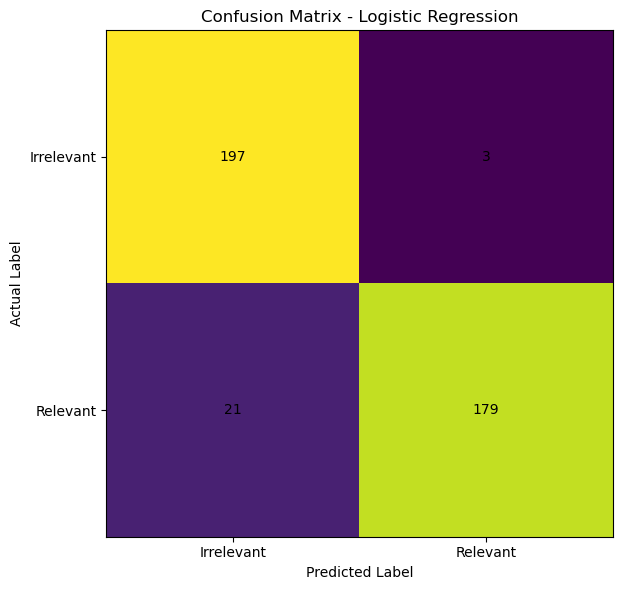

Object `at` not found.


In [ ]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Irrelevant", "Relevant"]
)

plt.yticks(
    [0, 1],
    ["Irrelevant", "Relevant"]
)

# Add the values inside the cells
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "visualizations/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
What are we looking at?

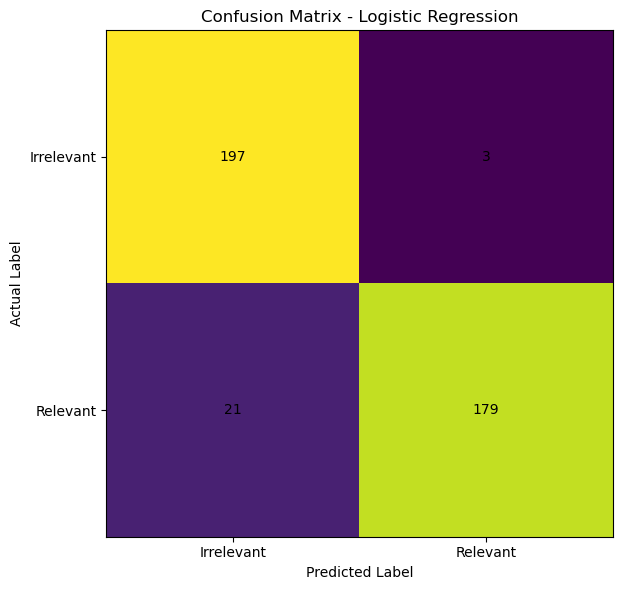

In [ ]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Irrelevant", "Relevant"]
)

plt.yticks(
    [0, 1],
    ["Irrelevant", "Relevant"]
)

# Add the values inside the cells
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "visualizations/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
relevant_probs = Results[Results["ACTUAL_LABEL"] == 1]["RELEVANT_PROBABILITIES"]
relevant_probs


150     0.756800
1006    0.880218
61      0.343619
1663    0.917669
1011    0.932488
          ...   
1804    0.921042
1205    0.938333
371     0.877662
1249    0.785628
963     0.943555
Name: RELEVANT_PROBABILITIES, Length: 200, dtype: float64

In [ ]:
irrelevant_probs = Results[Results["ACTUAL_LABEL"] == 0]["RELEVANT_PROBABILITIES"]
irrelevant_probs

1514    0.300679
52      0.465247
970     0.143574
1022    0.100732
655     0.069698
          ...   
278     0.230448
186     0.108433
1640    0.194872
214     0.233424
1314    0.160209
Name: RELEVANT_PROBABILITIES, Length: 200, dtype: float64

In [ ]:
print("Relevant questions:")
print(relevant_probs.describe())

print("\nIrrelevant questions:")
print(irrelevant_probs.describe())

Relevant questions:
count    200.000000
mean       0.824804
std        0.166438
min        0.214201
25%        0.824712
50%        0.877576
75%        0.921169
max        0.966861
Name: RELEVANT_PROBABILITIES, dtype: float64

Irrelevant questions:
count    200.000000
mean       0.163447
std        0.096427
min        0.058509
25%        0.099256
50%        0.145943
75%        0.192558
max        0.713511
Name: RELEVANT_PROBABILITIES, dtype: float64


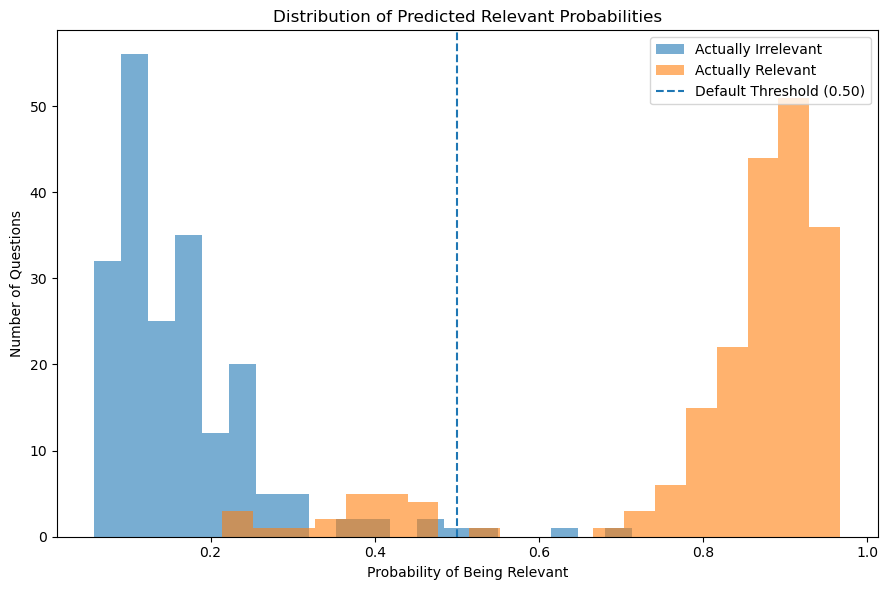

In [ ]:
plt.figure(figsize=(9, 6))

plt.hist(
    irrelevant_probs,
    bins=20,
    alpha=0.6,
    label="Actually Irrelevant"
)

plt.hist(
    relevant_probs,
    bins=20,
    alpha=0.6,
    label="Actually Relevant"
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Default Threshold (0.50)"
)

plt.title("Distribution of Predicted Relevant Probabilities")
plt.xlabel("Probability of Being Relevant")
plt.ylabel("Number of Questions")

plt.legend()

plt.tight_layout()

plt.savefig(
    "visualizations/probability_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
uncertain = Results[
    (Results["RELEVANT_PROBABILITIES"] >= 0.40) &
    (Results["RELEVANT_PROBABILITIES"] <= 0.60)
].sort_values("RELEVANT_PROBABILITIES")

display(uncertain)

,QUESTION,ACTUAL_LABEL,PREDICTION,RELEVANT_PROBABILITIES
55,How do I remove a stubborn stain from carpet?,0,0,0.403929
1147,How do I factory reset my laptop?,0,0,0.405811
781,What is the central theme of 'To Kill a Mockingbird'?,1,0,0.407979
865,"How does Ohm's law relate voltage, current, and resistance?",1,0,0.428300
1644,What techniques help with memorizing course material?,1,0,0.429050
1419,What is the derivative of 3x^3 + 2x?,1,0,0.431274
997,How does a catalyst speed up a chemical reaction?,1,0,0.434807
1792,What is the law of supply and demand?,1,0,0.445369
80,What is a metaphor and how is it used in poetry?,1,0,0.451064
1053,What is the difference between APA and MLA citation styles?,1,0,0.462560


In [ ]:
Results["DISTANCE_FROM_BOUNDARY"] = abs(Results["RELEVANT_PROBABILITIES"] - 0.5)
Results

,QUESTION,ACTUAL_LABEL,PREDICTION,RELEVANT_PROBABILITIES,distance_from_boundary,DISTANCE_FROM_BOUNDARY
1514,What is the best way to save money each month?,0,0,0.300679,0.199321,0.199321
52,What is the difference between 4G and 5G?,0,0,0.465247,0.034753,0.034753
150,What documents do I need for my application to Business Administration?,1,1,0.756800,0.256800,0.256800
970,Who sang Espresso?,0,0,0.143574,0.356426,0.356426
1022,What awards did Euphoria win?,0,0,0.100732,0.399268,0.399268
...,...,...,...,...,...,...
1249,What are Professor Ngwa's office hours?,1,1,0.785628,0.285628,0.285628
1640,What ingredients do I need for chocolate cake?,0,0,0.194872,0.305128,0.305128
214,What is the recipe for beef lasagna?,0,0,0.233424,0.266576,0.266576
1314,What genre is Taylor Swift known for?,0,0,0.160209,0.339791,0.339791


In [ ]:
most_uncertain = Results.sort_values("distance_from_boundary")

display(
    most_uncertain[
        [
            "QUESTION",
            "ACTUAL_LABEL",
            "PREDICTION",
            "RELEVANT_PROBABILITIES",
            "DISTANCE_FROM_BOUNDARY"
        ]
    ].head(20)
)

,QUESTION,ACTUAL_LABEL,PREDICTION,RELEVANT_PROBABILITIES,DISTANCE_FROM_BOUNDARY
1136,How do I keep pests away from my vegetable garden?,0,0,0.496361,0.003639
856,What are the fashion trends this year?,0,0,0.484152,0.015848
616,What is active recall and how does it help with learning?,1,1,0.516140,0.016140
177,How do I prepare a study schedule for finals week?,1,0,0.477459,0.022541
52,What is the difference between 4G and 5G?,0,0,0.465247,0.034753
1990,When is the next Olympics being held?,0,1,0.535248,0.035248
1053,What is the difference between APA and MLA citation styles?,1,0,0.462560,0.037440
80,What is a metaphor and how is it used in poetry?,1,0,0.451064,0.048936
1792,What is the law of supply and demand?,1,0,0.445369,0.054631
997,How does a catalyst speed up a chemical reaction?,1,0,0.434807,0.065193


<h2>Save the Model</h2>

In [ ]:
# Create model directory
os.makedirs("model", exist_ok=True)
# Label mapping
label_mapping = {
    0: "irrelevant",
    1: "relevant"
}


# Save the vectorizer and classifier together
model_data = {
    "vectorizer": tfidf_vectorizer,
    "classifier": Logistic_model,
    "label_mapping": label_mapping
}

joblib.dump(
    model_data,
    "model/relevance_gate.joblib"
)

print("Model saved successfully!")
print("Location: model/relevance_gate.joblib")

Model saved successfully!
Location: model/relevance_gate.joblib


<h2>Relevant gate function</h2>

In [ ]:
def relevance_gate(question, threshold=0.50):

    # Convert the question into TF-IDF features
    question_tfidf = tfidf_vectorizer.transform([question])

    # Get probability of each class
    probabilities = logistic_model.predict_proba(question_tfidf)[0]

    # Probability of being relevant
    relevant_probability = probabilities[1]

    # Apply threshold
    if relevant_probability >= threshold:
        label = "relevant"
        route = "Retrieval + LLM"
    else:
        label = "irrelevant"
        route = "Local out-of-scope reply"

    return {
        "question": question,
        "label": label,
        "probability": relevant_probability,
        "route": route
    }

<h2>estimate token savings by the gate</h2>

In [ ]:
#check the number of questions
total_questions = len(y_test_encoded)

print("Total questions:", total_questions)

Total questions: 400


In [ ]:
baseline_llm_calls = total_questions

print("Baseline LLM calls:", baseline_llm_calls)

Baseline LLM calls: 400


In [ ]:
optimized_llm_calls = (y_predicted == 1).sum()# to get the number of relevant questions only

print("Optimized LLM calls:", optimized_llm_calls)

Optimized LLM calls: 182


In [ ]:

avoided_calls = baseline_llm_calls - optimized_llm_calls# to get the number of avoided calls

print("Avoided LLM calls:", avoided_calls)

Avoided LLM calls: 218


In [ ]:
#percentage call reduction
avoidance_rate = (
    avoided_calls / baseline_llm_calls
) * 100

print(f"LLM call reduction: {avoidance_rate:.2f}%")

LLM call reduction: 54.50%


In [ ]:
# creating cost_summary
cost_summary = pd.DataFrame({
    "Metric": [
        "Total questions",
        "Baseline LLM calls",
        "Optimized LLM calls",
        "Avoided LLM calls",
        "LLM call reduction"
    ],
    "Value": [
        total_questions,
        baseline_llm_calls,
        optimized_llm_calls,
        avoided_calls,
        f"{avoidance_rate:.2f}%"
    ]
})

display(cost_summary)

,Metric,Value
0,Total questions,400
1,Baseline LLM calls,400
2,Optimized LLM calls,182
3,Avoided LLM calls,218
4,LLM call reduction,54.50%


In [ ]:
average_tokens_per_call = 1000

estimated_tokens_saved = (
    avoided_calls * average_tokens_per_call
)

In [ ]:
estimated_price_per_1k_tokens = 0.002

estimated_cost_saved = (
    estimated_tokens_saved / 1000
) * estimated_price_per_1k_tokens

print(
    f"Estimated cost saved: "
    f"${estimated_cost_saved:.4f}"
)

Estimated cost saved: $0.4360


<h2>estimate token savings by the gate</h2>

In [ ]:

# PAGE CONFIGURATION
st.set_page_config(
    page_title="Relevance Gate",
    page_icon="🎓",
    layout="centered")

# LOAD SAVED MODEL

@st.cache_resource
def load_model():

    model_data = joblib.load(
        "model/relevance_gate.joblib"
    )

    return (
        model_data["vectorizer"],
        model_data["classifier"],
        model_data["label_mapping"]
    )


tfidf_vectorizer, logistic_model, label_mapping = load_model()

# RELEVANCE GATE

def relevance_gate(question, threshold):

    # Convert question to TF-IDF
    question_tfidf = tfidf_vectorizer.transform(
        [question]
    )

    # Get probabilities
    probabilities = logistic_model.predict_proba(
        question_tfidf
    )[0]

    # Probability of relevant class
    relevant_probability = probabilities[1]

    # Apply threshold
    if relevant_probability >= threshold:

        label = "relevant"
        route = "Retrieval + LLM"

    else:

        label = "irrelevant"
        route = "Local out-of-scope reply"

    return label, relevant_probability, route

# USER INTERFACE

st.title("Relevance Gate")

st.write(
    "This system determines whether a question "
    "belongs to the academic domain before sending "
    "it to the RAG pipeline."
)

# THRESHOLD SLID

threshold = st.slider(
    "Relevance threshold",
    min_value=0.10,
    max_value=0.90,
    value=0.50,
    step=0.05
)

st.write(
    f"Current threshold: **{threshold:.2f}**"
)


# QUESTION INPUt

question = st.text_area(
    "Enter your question:",
    placeholder="Example: Is the final exam cumulative?"
)

# CHECK BUTTON

if st.button("Check Question"):

    if question.strip() == "":
        
        st.warning("Please enter a question.")

    else:

        label, probability, route = relevance_gate(
            question,
            threshold
        )

        st.subheader("Gate Decision")

        # Display decision
        if label == "relevant":

            st.success(
                f"RELEVANT — {probability:.2%}"
            )

            st.write(
                " This question will be forwarded "
                "to Retrieval + LLM."
            )

        else:

            st.info(
                f"IRRELEVANT — {probability:.2%}"
            )

            st.write(
                "This question receives a local "
                "out-of-scope response."
            )

        # Probability
        st.write(
            f"**Probability of relevance:** "
            f"{probability:.4f}"
        )

        # Routing
        st.write(
            f"**Routing:** {route}"
        )
